In [162]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
from scipy import stats

# Part 1: Handling missing values & Basic concepts in Probability

In [163]:
df = pd.read_csv('Cars.csv')

In [164]:
df.head()

,carname,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130.0,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130.0,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152.0,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109.0,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136.0,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [165]:
df.shape

(205, 24)

In [166]:
df.describe(include=['object'])

,carname,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
count,205,205,205,205,205,205,205,205,205,205
unique,147,2,2,2,5,3,2,7,7,8
top,toyota corona,gas,std,four,sedan,fwd,front,ohc,four,mpfi
freq,6,185,168,115,96,120,202,148,159,94


In [167]:
df.describe()

,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,194.000000,205.000000,185.000000,190.000000,205.000000,185.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,98.669588,174.049268,65.932973,53.738947,2555.565854,124.081081,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,5.934168,12.337289,2.113143,2.470452,520.680204,38.528771,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,94.500000,166.300000,64.200000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,97.000000,173.200000,65.500000,54.100000,2414.000000,110.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,101.800000,183.100000,66.600000,55.575000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,120.900000,208.100000,72.300000,59.800000,4066.000000,308.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


## Q1: How many null values are there in each column?

In [168]:
df.isnull().sum()

carname              0
fueltype             0
aspiration           0
doornumber           0
carbody              0
drivewheel           0
enginelocation       0
wheelbase           11
carlength            0
carwidth            20
carheight           15
curbweight           0
enginetype           0
cylindernumber       0
enginesize          20
fuelsystem           0
boreratio            0
stroke               0
compressionratio     0
horsepower           0
peakrpm              0
citympg              0
highwaympg           0
price                0
dtype: int64

### Q1_1: Replace the null value of column "wheelbase" with the max value of the same column

In [169]:
df['wheelbase'] = df['wheelbase'].fillna(df['wheelbase'].max())

### Q1_2: Replace the null value of column "carwidth" with the Min value of the same column

In [170]:
df['carwidth'] = df['carwidth'].fillna(df['carwidth'].min())

### Q1_3: Use Linear Interpolation to change the null value of column "carheight"

In [171]:
df['carheight'] = df['carheight'].interpolate(method='linear')

### Q1_4: Replace the null value of column "enginesize" with the mod of the same column and check how many null values we have

In [172]:
df['enginesize'] = df['enginesize'].fillna(df['enginesize'].mode()[0])
df.isnull().sum()

carname             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

## Q2: What is the Probability that the Car is Sedan ?

In [173]:
p_sedan = len(df[df['carbody'] == 'sedan']) / len(df)
p_sedan

0.4682926829268293

## Q3: What is the Probability that the car is Sedan and works with gas ?

In [174]:
p_sedan_and_gas = len(df[(df['carbody'] == 'sedan') & (df['fueltype'] == 'gas')]) / len(df)
p_sedan_and_gas

0.3951219512195122

## Q4: What is the probability that a car is Sedan given it is a gas fuel type?

In [175]:
gas_cars = df[df['fueltype'] == 'gas']
p_sedan_given_gas = len(gas_cars[gas_cars['carbody'] == 'sedan']) / len(gas_cars)
p_sedan_given_gas

0.43783783783783786

## Q5: Given that the car height is higer than 50, find the probability that the car engin size is greater than 130?

In [176]:
high_cars = df[df['carheight'] > 50]
p_engine_given_height = len(high_cars[high_cars['enginesize'] > 130]) / len(high_cars)
p_engine_given_height

0.2916666666666667

# Part 2: Probability Functions

## Q6: Load dataset 'students.csv' and show first rows, shape, and compute the skewness.

In [177]:
df_stud = pd.read_csv('students.csv')
print(df_stud.head())
print(df_stud.shape)
salary_skew = df_stud['salary'].skew()
salary_skew

   stud.id                 name  gender  age  height  weight    religion  \
0   833917  Gonzales, Christina  Female   19     160    64.8      Muslim   
1   898539       Lozano, T'Hani  Female   19     172    73.0       Other   
2   379678       Williams, Hanh  Female   22     168    70.6  Protestant   
3   807564          Nem, Denzel    Male   19     183    79.7       Other   
4   383291      Powell, Heather  Female   21     175    71.4    Catholic   

   nc.score semester                   major                       minor  \
0      1.91      1st       Political Science             Social Sciences   
1      1.56      2nd         Social Sciences  Mathematics and Statistics   
2      1.24      3rd         Social Sciences  Mathematics and Statistics   
3      1.37      2nd  Environmental Sciences  Mathematics and Statistics   
4      1.46      1st  Environmental Sciences  Mathematics and Statistics   

   score1  score2  online.tutorial  graduated  salary  
0     NaN     NaN             

np.float64(0.273835141614412)

## Q7: What is the probability that the salary is greater than 20000 and less than 30000?

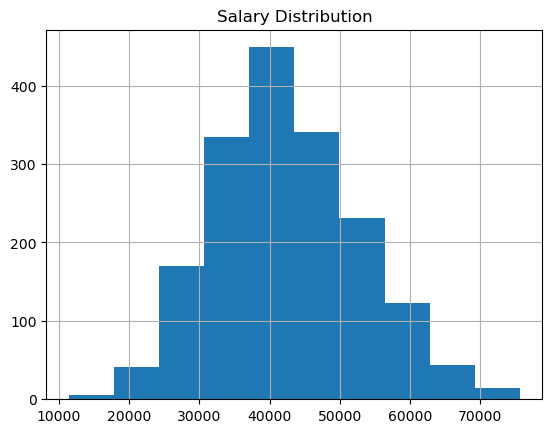

In [178]:
# 1.1) Plotting Histogram
df_stud['salary'].hist()
plt.title('Salary Distribution')
plt.show()

In [179]:
# 1.2) calculate the skewness
print(f"The distribution of the salary is: {'Normal' if abs(salary_skew) < 0.5 else 'Skewed'}")
salary_skew

The distribution of the salary is: Normal


np.float64(0.273835141614412)

In [180]:
# 2) Compute mean and std
mean_sal = df_stud['salary'].mean()
std_sal = df_stud['salary'].std()
print(f"Mean: {mean_sal}, Std: {std_sal}")

Mean: 42522.112364181405, Std: 10333.139905547341


In [181]:
# 3) Convert to Z-scores
z1 = (20000 - mean_sal) / std_sal
z2 = (30000 - mean_sal) / std_sal
print(f"Z-scores: {z1}, {z2}")

Z-scores: -2.1796000605866586, -1.2118400097785296


In [182]:
# 4) Calculate the probability
prob_salary = stats.norm.cdf(z2) - stats.norm.cdf(z1)
prob_salary

np.float64(0.09814325462173674)

## Q8: A factory produces 200 chips with defect rate 8%.

In [183]:
# 1. The distribution name of this problem is Binomial Distribution
n = 200
p = 0.08

In [184]:
# 2) What is the probability of getting exactly 14 defective chips?
stats.binom.pmf(14, n, p)

np.float64(0.0954115649226197)

In [185]:
# 3) At least 14 defective?
1 - stats.binom.cdf(13, n, p)

np.float64(0.7357078859493741)

In [186]:
# 4) At most 15 defective?
stats.binom.cdf(15, n, p)

np.float64(0.4625822359332888)

In [187]:
# 5) Expected defects and standard deviation
exp = n * p
std = np.sqrt(n * p * (1 - p))
print(f"Expected: {exp}, Std Dev: {std}")

Expected: 16.0, Std Dev: 3.8366652186501757
